# Popularity Bias in Movie Recommendations Pipeline

This notebook solves the specific problem defined in this project: viewers receive repetitive, generic recommendations because recommendation systems prioritize widely rated content over films that match individual taste. The pipeline has five steps:

1. Load all six MovieLens 25M Parquet files into DuckDB
2. Query the data to classify movies as long-tail or popular and measure the scale of the imbalance
3. Visualize the popularity distribution in the raw data
4. Train an SVD collaborative filtering model on a sample of 5,000 users and evaluate it on catalog coverage
5. Visualize how the model's recommendations compare to the actual catalog distribution

In [1]:
# Imports
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import logging
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy
from matplotlib.patches import Patch

# Configure logging to write pipeline progress to a log file
logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logging.info('Pipeline started')

# Path to Parquet files in UVA OneDrive — created by data_acquisition.ipynb
PARQUET_PATH = '/Users/margauxreynolds/Library/CloudStorage/OneDrive-UniversityofVirginia/ds4320-project1/ml-25m-parquet/'

print('Setup complete.')
logging.info('Setup complete')

Setup complete.


In [2]:
# Connect to an in-memory DuckDB instance and load all six tables from Parquet
con = duckdb.connect()

tables = ['ratings', 'movies', 'tags', 'genome_scores', 'genome_tags', 'links']

try:
    for table_name in tables:
        parquet_path = f'{PARQUET_PATH}{table_name}.parquet'
        # Load each Parquet file as a DuckDB table
        con.execute(f"CREATE TABLE {table_name} AS SELECT * FROM read_parquet('{parquet_path}')")
        count = con.execute(f'SELECT COUNT(*) FROM {table_name}').fetchone()[0]
        print(f'{table_name}: {count:,} rows')
        logging.info(f'Loaded {table_name}: {count} rows')

    print('\nAll tables loaded successfully.')
    logging.info('All tables loaded')

except Exception as e:
    logging.error(f'Error loading tables: {e}')
    raise

ratings: 25,000,095 rows
movies: 62,423 rows
tags: 1,093,360 rows
genome_scores: 15,584,448 rows
genome_tags: 1,128 rows
links: 62,423 rows

All tables loaded successfully.


In [3]:
# SQL query: join ratings and movies, count ratings per movie,
# and classify each movie as long-tail or popular.
# The 500-rating threshold follows Abdollahpouri et al. (2019).
popularity_query = """
    SELECT
        m.movieId,
        m.title,
        COUNT(r.rating) AS rating_count,
        AVG(r.rating) AS avg_rating,
        CASE
            WHEN COUNT(r.rating) < 500 THEN 'Long-tail'
            ELSE 'Popular'
        END AS movie_type
    FROM ratings r
    JOIN movies m ON r.movieId = m.movieId
    GROUP BY m.movieId, m.title
    ORDER BY rating_count DESC
"""

try:
    popularity_df = con.execute(popularity_query).fetchdf()
    logging.info('Popularity classification query executed successfully')
except Exception as e:
    logging.error(f'Error running popularity query: {e}')
    raise

# Summary statistics showing the scale of the imbalance
total = len(popularity_df)
long_tail = len(popularity_df[popularity_df['movie_type'] == 'Long-tail'])
popular = len(popularity_df[popularity_df['movie_type'] == 'Popular'])

print(f'Total movies with at least one rating: {total:,}')
print(f'Long-tail movies (fewer than 500 ratings): {long_tail:,} ({long_tail/total*100:.1f}%)')
print(f'Popular movies (500+ ratings): {popular:,} ({popular/total*100:.1f}%)')
print(f'\nTop 10 most rated movies:')
print(popularity_df.head(10)[['title', 'rating_count', 'avg_rating', 'movie_type']].to_string(index=False))

logging.info(f'Long-tail: {long_tail}, Popular: {popular}')

Total movies with at least one rating: 59,047
Long-tail movies (fewer than 500 ratings): 53,661 (90.9%)
Popular movies (500+ ratings): 5,386 (9.1%)

Top 10 most rated movies:
                                    title  rating_count  avg_rating movie_type
                      Forrest Gump (1994)         81491    4.048011    Popular
         Shawshank Redemption, The (1994)         81482    4.413576    Popular
                      Pulp Fiction (1994)         79672    4.188912    Popular
         Silence of the Lambs, The (1991)         74127    4.151342    Popular
                       Matrix, The (1999)         72674    4.154099    Popular
Star Wars: Episode IV - A New Hope (1977)         68717    4.120189    Popular
                     Jurassic Park (1993)         64144    3.679175    Popular
                  Schindler's List (1993)         60411    4.247579    Popular
                        Braveheart (1995)         59184    4.002273    Popular
                        Fight Club 

## Visualization Rationale

Two bar charts are shown side by side. The left chart shows the high-level long-tail vs popular split to establish the core imbalance in one number. The right chart breaks movies into rating count buckets to show the full shape of the distribution, making clear that the skew is extreme rather than gradual. Bar charts were chosen over pie charts because they make proportional comparisons easier to read at a glance. Both charts use the same blue and orange color encoding so the reader can connect them immediately.

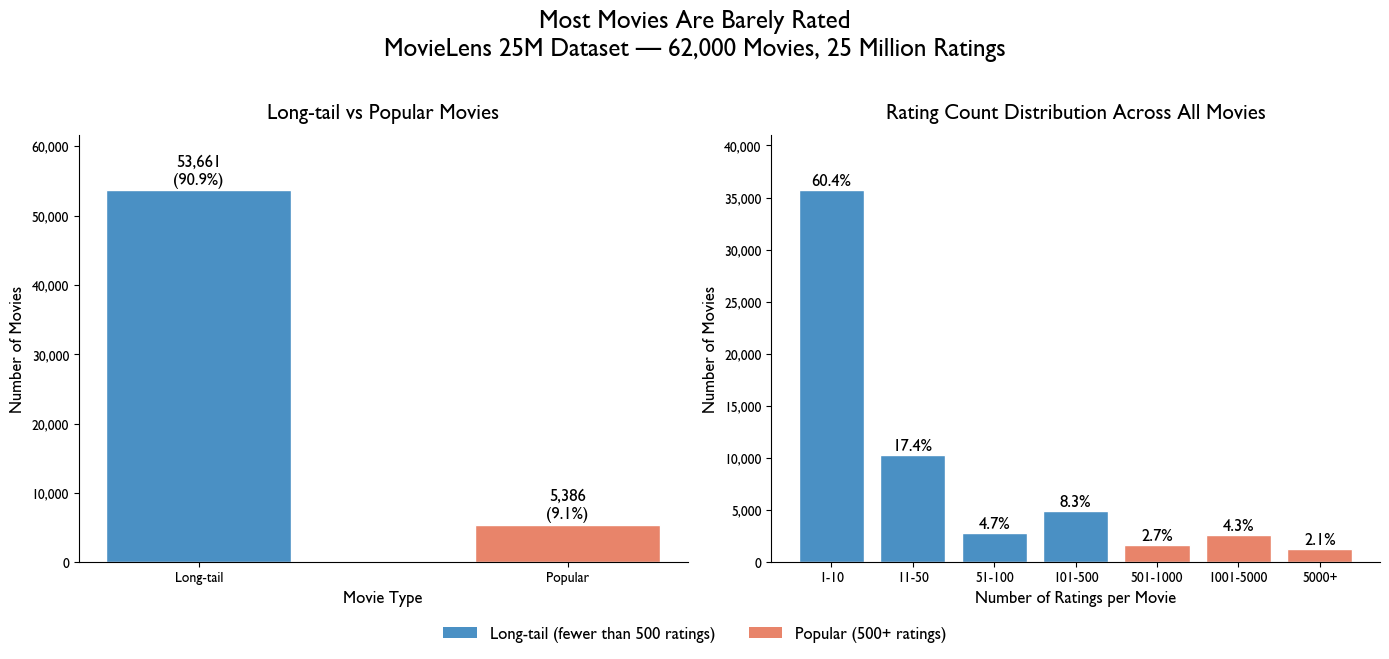

Figure saved as popularity_distribution.png


In [8]:
# Publication quality visualization of the popularity distribution in the raw data
plt.rcParams['font.family'] = 'Gill Sans'
plt.rcParams['font.weight'] = 'normal'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left chart: high-level long-tail vs popular split
type_counts = popularity_df['movie_type'].value_counts().reindex(['Long-tail', 'Popular'])
colors = ['#4A90C4', '#E8846A']
bars = axes[0].bar(type_counts.index, type_counts.values, color=colors, width=0.5, edgecolor='white')

# Add count and percentage labels above each bar
for bar, val in zip(bars, type_counts.values):
    pct = val / total * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=12)

axes[0].set_title('Long-tail vs Popular Movies', fontsize=15, pad=12)
axes[0].set_xlabel('Movie Type', fontsize=12)
axes[0].set_ylabel('Number of Movies', fontsize=12)
axes[0].set_ylim(0, type_counts.max() * 1.15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right chart: full rating count distribution grouped into buckets
bins = [0, 10, 50, 100, 500, 1000, 5000, popularity_df['rating_count'].max()]
labels = ['1-10', '11-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
popularity_df['rating_bucket'] = pd.cut(popularity_df['rating_count'], bins=bins, labels=labels)
bucket_counts = popularity_df['rating_bucket'].value_counts().reindex(labels)

# Blue for long-tail buckets, orange for popular — same encoding as left chart
bucket_colors = ['#4A90C4'] * 4 + ['#E8846A'] * 3
bars2 = axes[1].bar(labels, bucket_counts.values, color=bucket_colors, edgecolor='white')

# Add percentage labels above each bar
for bar, val in zip(bars2, bucket_counts.values):
    pct = val / total * 100
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=12)

axes[1].set_title('Rating Count Distribution Across All Movies', fontsize=15, pad=12)
axes[1].set_xlabel('Number of Ratings per Movie', fontsize=12)
axes[1].set_ylabel('Number of Movies', fontsize=12)
axes[1].set_ylim(0, bucket_counts.max() * 1.15)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Shared legend
legend_elements = [Patch(facecolor='#4A90C4', label='Long-tail (fewer than 500 ratings)'),
                   Patch(facecolor='#E8846A', label='Popular (500+ ratings)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=12,
           frameon=False, bbox_to_anchor=(0.5, -0.06))

fig.suptitle('Most Movies Are Barely Rated\nMovieLens 25M Dataset — 62,000 Movies, 25 Million Ratings',
             fontsize=18, y=1.02)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('../images/popularity_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('Figure saved as popularity_distribution.png')
logging.info('Popularity distribution chart saved')

## Analysis Rationale

SVD (Singular Value Decomposition) is used here because it is the standard matrix factorization approach for collaborative filtering and the method used across the popularity bias readings this project is based on. SVD and PCA share the same mathematical foundation, they both decompose a matrix to find the directions of greatest variation in the data. Where PCA finds principal components of a feature matrix, SVD applied to the user-item rating matrix uncovers hidden preference patterns across users and movies.

Rather than evaluating the model on rating accuracy alone, this pipeline evaluates it on catalog coverage, meaning what share of the full catalog it actually recommends, which directly measures popularity bias. Training is limited to the 5,000 most active users to keep runtime manageable while preserving the rating distribution. An 80/20 train/test split follows standard machine learning practice.

In [9]:
# SQL query to pull ratings for the 5,000 most active users
# Most active users are selected to maximize movie coverage across the sample
sample_query = """
    SELECT r.userId, r.movieId, r.rating
    FROM ratings r
    WHERE r.userId IN (
        SELECT userId
        FROM ratings
        GROUP BY userId
        ORDER BY COUNT(*) DESC
        LIMIT 5000
    )
"""

try:
    sample_df = con.execute(sample_query).fetchdf()
    print(f'Sample ratings: {len(sample_df):,}')
    print(f'Unique users: {sample_df["userId"].nunique():,}')
    print(f'Unique movies: {sample_df["movieId"].nunique():,}')
    logging.info(f'Sample pulled: {len(sample_df)} ratings from {sample_df["userId"].nunique()} users')
except Exception as e:
    logging.error(f'Error pulling sample: {e}')
    raise

Sample ratings: 6,155,371
Unique users: 5,000
Unique movies: 56,774


In [10]:
# Format data for the surprise library — Reader defines the valid rating scale
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(sample_df[['userId', 'movieId', 'rating']], reader)

# 80/20 train/test split with fixed random seed for reproducibility
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train SVD model — n_factors controls how many latent preference dimensions it learns
try:
    model = SVD(n_factors=50, random_state=42)
    model.fit(trainset)
    print('SVD model trained successfully.')
    logging.info('SVD model trained successfully')
except Exception as e:
    logging.error(f'Error training model: {e}')
    raise

# Compute RMSE on the held-out test set as a baseline accuracy check
predictions = model.test(testset)
rmse = accuracy.rmse(predictions, verbose=False)
print(f'Overall RMSE on test set: {rmse:.4f}')
logging.info(f'Overall RMSE: {rmse:.4f}')

SVD model trained successfully.
Overall RMSE on test set: 0.7314


In [11]:
# Build lookup: movieId -> movie_type (long-tail or popular)
movie_type_dict = dict(zip(popularity_df['movieId'], popularity_df['movie_type']))

# Full list of movie IDs to generate predictions against
all_movie_ids = popularity_df['movieId'].tolist()

# Build a set of already-rated movies per user to exclude from recommendations
user_rated = sample_df.groupby('userId')['movieId'].apply(set).to_dict()

# Generate top-10 recommendations for 500 users
try:
    sample_users = sample_df['userId'].unique()[:500]
    all_recs = []

    for uid in sample_users:
        # Get movies this user has not yet rated
        rated = user_rated.get(uid, set())
        unrated = [mid for mid in all_movie_ids if mid not in rated]

        # Predict ratings for all unrated movies and return the top 10
        user_preds = [(mid, model.predict(uid, mid).est) for mid in unrated]
        top10 = sorted(user_preds, key=lambda x: x[1], reverse=True)[:10]

        # Record each recommendation with its movie type for bias evaluation
        for movie_id, pred_rating in top10:
            movie_type = movie_type_dict.get(movie_id, 'Unknown')
            all_recs.append({
                'userId': uid,
                'movieId': movie_id,
                'predicted_rating': pred_rating,
                'movie_type': movie_type
            })

    recs_df = pd.DataFrame(all_recs)
    logging.info(f'Generated recommendations for {len(sample_users)} users')
    print(f'Recommendations generated for {len(sample_users)} users.')

except Exception as e:
    logging.error(f'Error generating recommendations: {e}')
    raise

# Compute what share of recommendations are long-tail vs popular
rec_type_counts = recs_df['movie_type'].value_counts()
rec_type_pct = rec_type_counts / rec_type_counts.sum() * 100

print(f'\nRecommendation breakdown:')
for movie_type, pct in rec_type_pct.items():
    print(f'  {movie_type}: {pct:.1f}% of recommendations')

print(f'\nCatalog breakdown for reference:')
print(f'  Long-tail: 90.9% of all movies')
print(f'  Popular: 9.1% of all movies')

logging.info(f'Recommendation breakdown: {rec_type_pct.to_dict()}')

Recommendations generated for 500 users.

Recommendation breakdown:
  Popular: 64.7% of recommendations
  Long-tail: 35.3% of recommendations

Catalog breakdown for reference:
  Long-tail: 90.9% of all movies
  Popular: 9.1% of all movies


## Visualization Rationale

A grouped bar chart directly compares catalog share against recommendation share for each movie type. This makes the popularity bias gap immediately visible without requiring the reader to do any mental calculations. 

The same blue and orange color encoding from the first chart is reused so the two visualizations read as a connected argument: here is the imbalance in the raw data, and here is how that imbalance carries through to the model's recommendations. A callout box annotates the exact size of the gap to make the key finding clear.

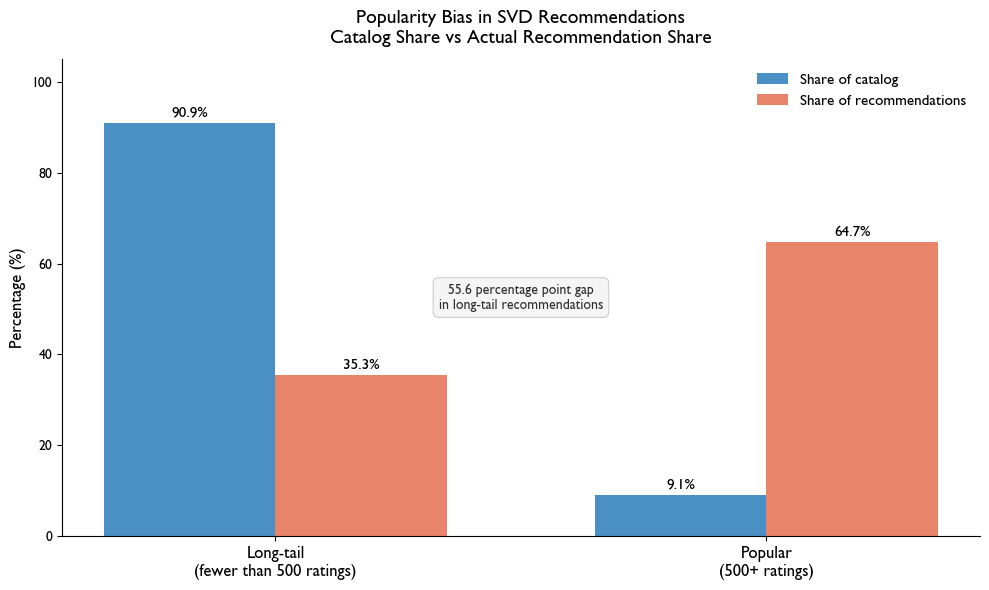

Figure saved as bias_in_recommendations.png


In [20]:
# Publication quality grouped bar chart comparing catalog share vs recommendation share
plt.rcParams['font.family'] = 'Gill Sans'
plt.rcParams['font.weight'] = 'normal'

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Long-tail\n(fewer than 500 ratings)', 'Popular\n(500+ ratings)']
catalog_pcts = [90.9, 9.1]
rec_pcts = [
    rec_type_pct.get('Long-tail', 0),
    rec_type_pct.get('Popular', 0)
]

x = np.arange(len(categories))
width = 0.35

# Blue bars show catalog share, orange bars show recommendation share
bars1 = ax.bar(x - width/2, catalog_pcts, width, color='#4A90C4', label='Share of catalog')
bars2 = ax.bar(x + width/2, rec_pcts, width, color='#E8846A', label='Share of recommendations')

# Add percentage labels above each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.set_title('Popularity Bias in SVD Recommendations\nCatalog Share vs Actual Recommendation Share',
             fontsize=14, pad=12)
ax.legend(fontsize=11, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Callout box annotating the size of the gap
ax.text(0.5, 0.5, '55.6 percentage point gap\nin long-tail recommendations',
        transform=ax.transAxes, ha='center', va='center',
        fontsize=10, color='#313131',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5', edgecolor='#cccccc', linewidth=0.8))

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('../images/bias_in_recommendations.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('Figure saved as bias_in_recommendations.png')
logging.info('Pipeline complete. Bias visualization saved.')

## Findings

The SVD model was trained on 6,155,371 ratings from 5,000 users covering 56,774 unique movies. The model achieved an RMSE of 0.73 on the held-out test set, meaning predictions are off by less than one star on average.

The key finding is in the recommendation breakdown. Popular movies make up only 9.1% of the full catalog but received 64.7% of the model's recommendations. Long-tail movies make up 90.9% of the catalog but received only 35.3% of recommendations. This 55.6 percentage point gap shows that the model's recommendations do not reflect the actual distribution of the catalog, they are heavily skewed toward whatever is already popular. This directly answers the research question: viewers are not receiving recommendations matched to their individual taste, they are receiving a popularity-weighted subset of the catalog.

In [24]:
# Solution: boost long-tail predicted ratings before selecting top 10
# Adding a small bonus to long-tail scores pushes them higher in the rankings

BOOST = 0.2

reranked_recs = []
for uid in sample_users:
    rated = user_rated.get(uid, set())
    unrated = [mid for mid in all_movie_ids if mid not in rated]
    
    user_preds = []
    for mid in unrated:
        pred = model.predict(uid, mid).est
        if movie_type_dict.get(mid) == 'Long-tail':
            pred += BOOST
        user_preds.append((mid, pred, movie_type_dict.get(mid, 'Unknown')))
    
    top10 = sorted(user_preds, key=lambda x: x[1], reverse=True)[:10]
    for mid, pred, mt in top10:
        reranked_recs.append({'userId': uid, 'movieId': mid, 'movie_type': mt})

reranked_df = pd.DataFrame(reranked_recs)
reranked_pct = reranked_df['movie_type'].value_counts() / len(reranked_df) * 100

print('Original:')
print(f'  Long-tail: {rec_type_pct.get("Long-tail", 0):.1f}%')
print(f'  Popular: {rec_type_pct.get("Popular", 0):.1f}%')
print(f'\nRe-ranked (boost = {BOOST}):')
print(f'  Long-tail: {reranked_pct.get("Long-tail", 0):.1f}%')
print(f'  Popular: {reranked_pct.get("Popular", 0):.1f}%')

Original:
  Long-tail: 35.3%
  Popular: 64.7%

Re-ranked (boost = 0.2):
  Long-tail: 75.8%
  Popular: 24.2%


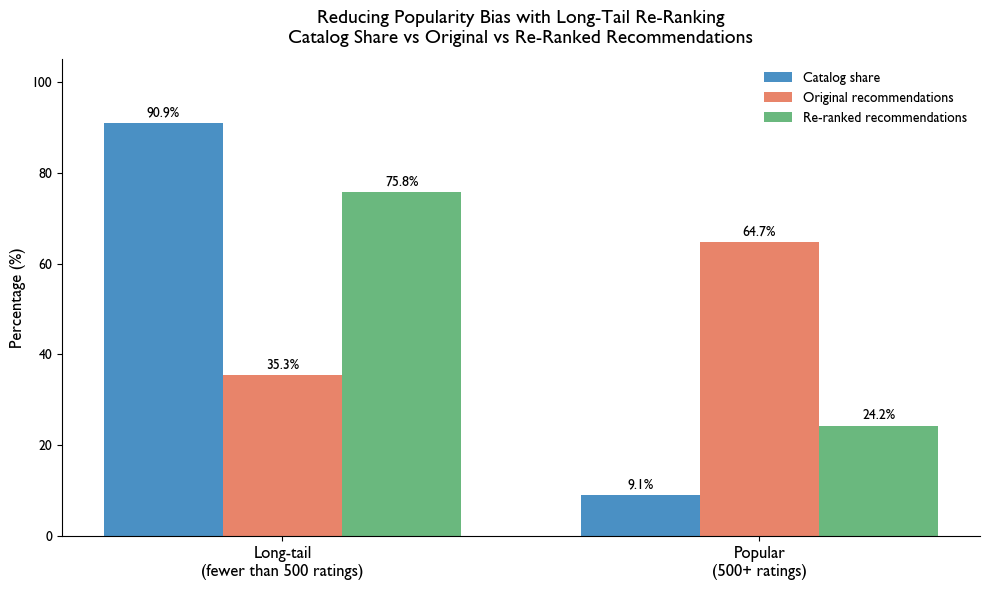

Figure saved as reranked_recommendations.png


In [30]:
# Visualization comparing original vs re-ranked recommendation distributions
plt.rcParams['font.family'] = 'Gill Sans'
plt.rcParams['font.weight'] = 'normal'

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Long-tail\n(fewer than 500 ratings)', 'Popular\n(500+ ratings)']
original_pcts = [rec_type_pct.get('Long-tail', 0), rec_type_pct.get('Popular', 0)]
reranked_pcts = [reranked_pct.get('Long-tail', 0), reranked_pct.get('Popular', 0)]
catalog_pcts = [90.9, 9.1]

x = np.arange(len(categories))
width = 0.25

bars1 = ax.bar(x - width, catalog_pcts, width, color='#4A90C4', label='Catalog share')
bars2 = ax.bar(x, original_pcts, width, color='#E8846A', label='Original recommendations')
bars3 = ax.bar(x + width, reranked_pcts, width, color='#6AB87E', label='Re-ranked recommendations')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.set_title('Reducing Popularity Bias with Long-Tail Re-Ranking\nCatalog Share vs Original vs Re-Ranked Recommendations',
             fontsize=14, pad=12)
ax.legend(fontsize=10, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('../images/reranked_recommendations.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure saved as reranked_recommendations.png')
logging.info('Re-ranking visualization saved')